<a href="https://colab.research.google.com/github/HarshMajmundar31/Mobile-dataset-Analysis-2025/blob/main/Mobile_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Average Specs by Company (₹20k - ₹30k) ---
                 RAM_GB   Battery_mAh         Price
Company Name                                       
Apple          3.000000   8612.000000  29900.000000
Honor          6.571429   5140.476190  26237.095238
Infinix       10.200000   5580.000000  26199.000000
Lenovo         6.000000   3350.000000  21400.000000
Motorola       7.619048   4838.095238  26903.761905
Nokia          6.000000   5000.000000  22999.000000
OnePlus        7.500000   4451.875000  25624.000000
Oppo           9.250000   4469.791667  25207.416667
POCO           6.400000   5008.500000  25699.000000
Poco           8.000000  10000.000000  24999.000000
Realme         7.619048   5990.476190  24701.714286
Samsung        6.428571   5385.000000  24712.642857
Tecno          7.111111   5966.666667  27554.555556
Vivo           7.000000   4166.538462  25650.076923
Xiaomi         7.142857   5087.142857  25713.285714


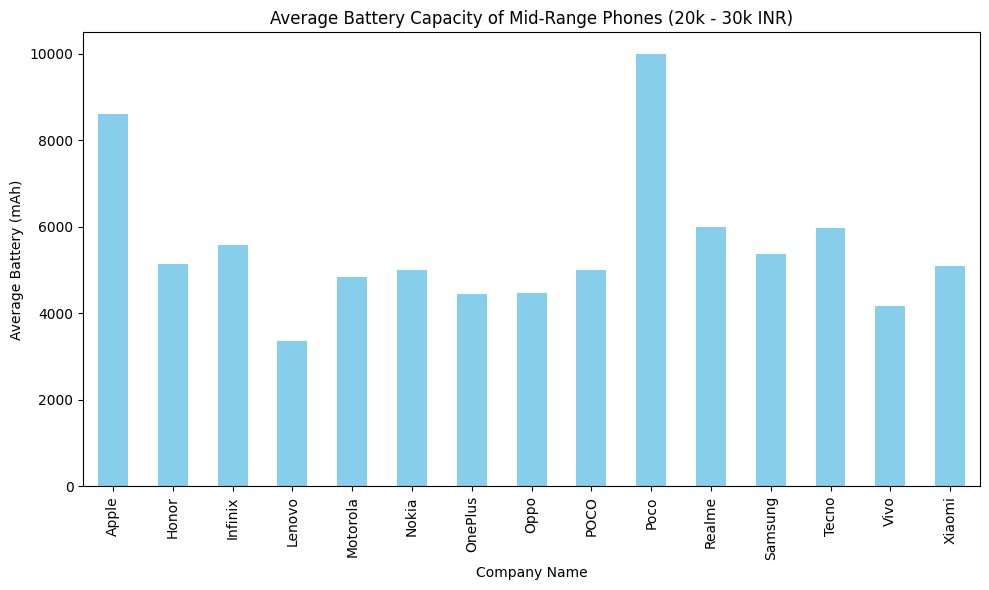

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the "Mobiles Dataset (2025)" with latin1 encoding to handle special characters
df = pd.read_csv('Mobiles Dataset (2025).csv', encoding='latin1')

# Select the specific columns available in this dataset
df = df[['Company Name', 'Launched Price (India)', 'RAM', 'Battery Capacity']]

# Clean the Price column (Remove 'INR ' and commas, then convert to numbers)
df['Price'] = df['Launched Price (India)'].str.replace('INR ', '', regex=False).str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Clean the RAM column (Remove 'GB' text and convert to numbers)
df['RAM_GB'] = df['RAM'].str.replace('GB', '', regex=False).str.strip()
df['RAM_GB'] = pd.to_numeric(df['RAM_GB'], errors='coerce')

# Clean the Battery column (Remove 'mAh' text and convert to numbers)
df['Battery_mAh'] = df['Battery Capacity'].str.replace('mAh', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['Battery_mAh'] = pd.to_numeric(df['Battery_mAh'], errors='coerce')

# Remove rows where data is missing or couldn't be converted
df = df.dropna(subset=['Price', 'RAM_GB', 'Battery_mAh'])

# Filter for the mid-range segment (₹20,000 to ₹30,000)
mid_range_df = df[(df['Price'] >= 20000) & (df['Price'] <= 30000)]

# Group by 'Company Name' and calculate the average RAM, Battery, and Price
brand_averages = mid_range_df.groupby('Company Name')[['RAM_GB', 'Battery_mAh', 'Price']].mean()

# Print the calculated averages to the console
print("--- Average Specs by Company (₹20k - ₹30k) ---")
print(brand_averages)

# Create a bar chart for Average Battery Capacity
plt.figure(figsize=(10, 6))
brand_averages['Battery_mAh'].plot(kind='bar', color='skyblue')

# Add titles and labels to the chart
plt.title('Average Battery Capacity of Mid-Range Phones (20k - 30k INR)')
plt.xlabel('Company Name')
plt.ylabel('Average Battery (mAh)')

# Display the chart
plt.tight_layout()
plt.show()